Import libraries
- numpy
- scikit-image

In [97]:
import numpy as np
import skimage as sk
import matplotlib.pyplot as plt

# Farbbilder und Spiegelung

1. Lesen Sie ein Bild mit Hilfe von scikit-image ein und lassen Sie sich das Bild anzeigen.

(333, 500, 3)


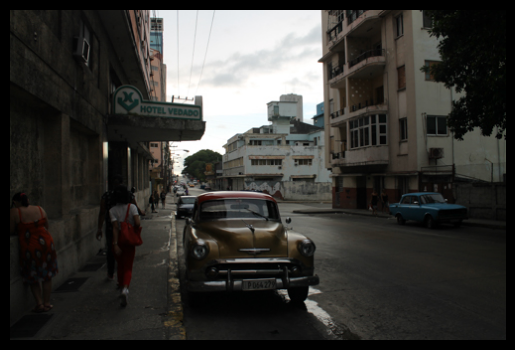

In [98]:
# read image using sk
image = sk.io.imread('bild01.jpg')

# show image using matplotlib since sk.io.imshow() is depreciated
plt.axis('off') #since image had distorted colors
plt.imshow(image)
print(image.shape)

2. Untersuchen Sie den Datentyp des eingelesenen Bildes. Wie ist ein Numpy Array aufge-
baut?

Das bild ist ein 3 dimensionales numpy array

pixel:     [255,  10,  30]

red: 255

green: 10

blue: 30

In [99]:
# datatype
print(f'image is a {image.ndim} dimensional {type(image).__name__}')
print(
    f'shape: {image.shape}',
    f'\ndtype: {image.dtype}'
    f'\nsize: {image.size} elements in the array'
    f'\nstrides: {image.strides} -> {image.strides[0]} byte step to next row, {image.strides[1]} byte per columns, {image.strides[2]} 1 byte for color channels/rgb',
)

print(image[0, 0])

image is a 3 dimensional ndarray
shape: (333, 500, 3) 
dtype: uint8
size: 499500 elements in the array
strides: (1500, 3, 1) -> 1500 byte step to next row, 3 byte per columns, 1 1 byte for color channels/rgb
[34 29 25]


3. Lassen Sie sich die drei Farbkan¨ale eines Bildes getrennt anzeigen.

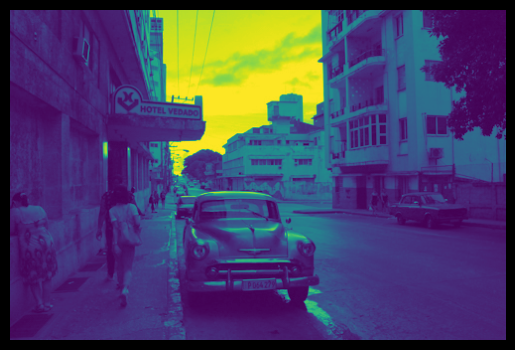

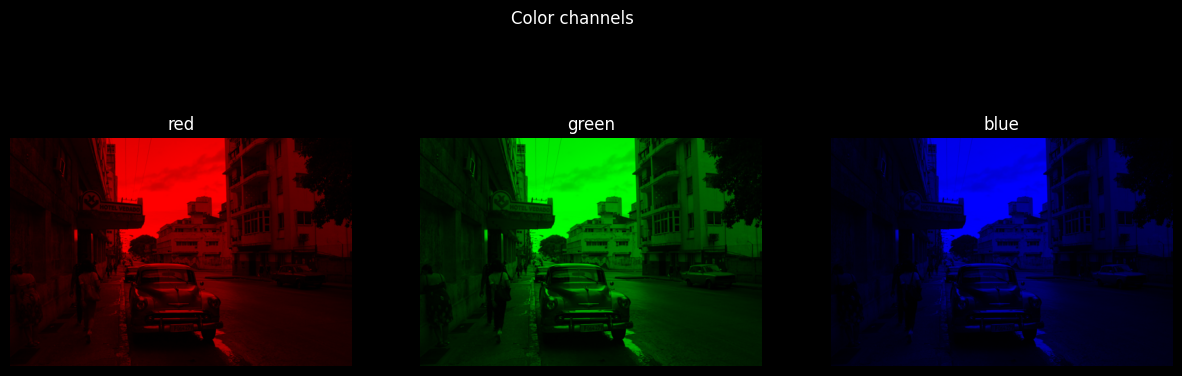

In [100]:
# to show the 3 channels
# isolate the channels
R = image[:, :, 0]
G = image[:, :, 1]
B = image[:, :, 2]

plt.imshow(R)
plt.axis('off')

# create black image in exact same shape and fill with r/g/b slots
R_img = np.zeros_like(image); R_img[:,:,0] = R
G_img = np.zeros_like(image); G_img[:,:,1] = G
B_img = np.zeros_like(image); B_img[:,:,2] = B

# show images
fig, axis = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Color channels')

axis[0].imshow(R_img)  # ← R_img not R
axis[0].axis('off')
axis[0].set_title('red')

axis[1].imshow(G_img)  # ← G_img not G
axis[1].axis('off')
axis[1].set_title('green')

axis[2].imshow(B_img)  # ← B_img not B
axis[2].axis('off')
axis[2].set_title('blue');

4. Implementieren Sie eine Funktion, die ein eingelesenes Bild wahlweise horizontal oder
vertikal spiegelt. (Verwenden Sie hierf¨ur keine Numpy Funktionen.)

Text(0.5, 1.0, 'Flipped image')

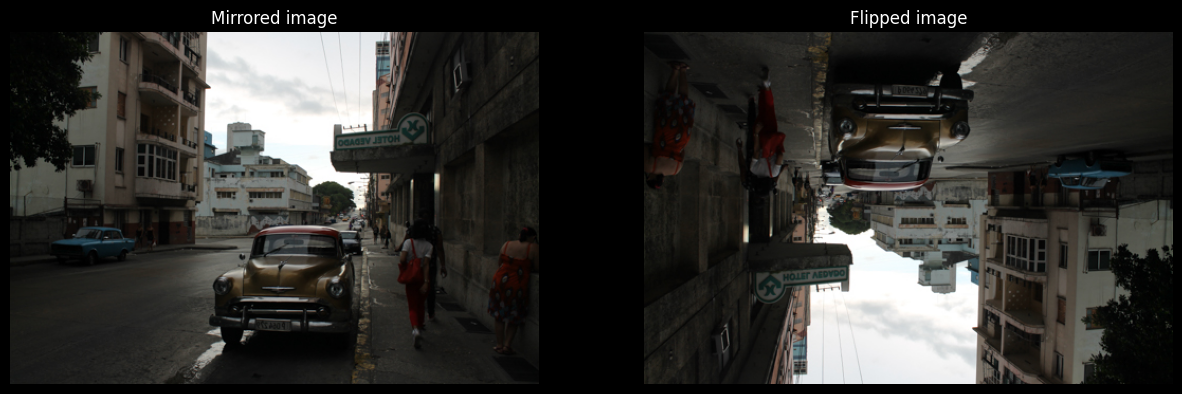

In [101]:
# reverses x-axis (rows, columns -> reversed)
def mirror(image_array):
    return image_array[:, ::-1, :]

# reverses y-axis (rows -> reversed, columns)
def flip(image_array):
    return image_array[::-1, :, :]

mirrored_image = mirror(image)
flipped_image = flip(image)

fig, axis = plt.subplots(1, 2, figsize=(15, 5))

axis[0].imshow(mirrored_image)
axis[0].axis('off')
axis[0].set_title('Mirrored image')

axis[1].imshow(flipped_image)
axis[1].axis('off')
axis[1].set_title('Flipped image')


# Histogramme, Binning und Lookup-Tabellen

Ein Histogram ist eine Häufigkeitsverteilung und beschreiben die Häufigkeit der einzelnen Intensitätswerte (wie viele pixel mit einem pro wert z.B. bei Greyscale -> wie oft tritt ein wert von 0-255 pro pixel auf)

Histogram zeigt wichtige eigenschaften:
- Kontrast, Dynamik, Probleme einer Bildaufnahme
- Helligkeit: viele Pixel nahe 255 -> helles Bild, nahe 0 -> dunkles Bild
- Kontrast: breite Verteilung -> hoher kontrast, schmale Verteilung -> niedriger Kontrast

`original bild kann nicht aus histogram rekonstruiert werden`

Kontrast:
- Bereich von Intensitätsstufen, die in einem Bild effektiv genutzt werden
- voller Kontrast -> nutzt gesamten bereich von intensitätswerten

Dynamik:
- Anzahl verschiedener Pixelwerte in einem Bild
- Idealfall -> alle Anzahl von Pixelwerten K voll ausgeschöpft
- dynamik kann nicht erhöht werden

Sättigung (Clipping/Saturation):
Ideal:
- Kontrastbereich der Kamera > Lichtintensität der Szene
- Histogramm läuft an beiden Seiten glatt aus
- Alle Intensitätswerte werden korrekt erfasst
Realität:
- Helligkeitswerte außerhalb des Sensorbereichs werden "abgeschnitten"
- Führt zu Spitzen (Peaks) an den Enden des Histogramms (bei 0 oder 255)
- Informationen gehen verloren!

Auswirkungen von Bildkompression auf das Histogramm:

GIF-Kompression (Farbquantisierung):
- Reduziert Farben/Intensitäten auf wenige Werte (z.B. 256 Farben)
- Histogramm zeigt deutliche Linienstruktur (isolierte Spitzen, Lücken dazwischen)
- Effekt ist NICHT rückgängig zu machen!
- Auch wenn Bild später als TIFF/JPEG gespeichert wird → Spuren bleiben sichtbar
1. GIF-Kompression:
   - Viele Intensitäten werden zusammengefasst
   - Histogramm: wenige isolierte Linien mit Lücken dazwischen
2. JPEG-Kompression (ungeeignet für einfache Grafiken):
   - Erzeugt neue, vorher nicht vorhandene Intensitätswerte
   - Histogramm: neue unerwartete Werte tauchen auf → Artefakte


Lesen Sie die Bilder mit Hilfe von scikit-image ein.

In [102]:
bild1 = sk.io.imread('bild01.jpg')
bild2 = sk.io.imread('bild02.png')
bild3 = sk.io.imread('bild03.jpg')
bild4 = sk.io.imread('bild04.jpg')
bild5 = sk.io.imread('bild05.png')

Schreiben Sie einen Funktion, die das Histogramm eines 8-Bit-Graustufenbildes (256
Intensit¨atsstufen) berechnet.

- Zunächst muss eine Funktion geschrieben werden, die ein RGB-Bild in ein Graustufen-
bild (mit nur einem Kanal) umwandelt.

-> entweder avg channels

-> weighted avg
codierung von analogen TV-Farbsignalen bekannten Gewichte
wR = 0.299 wG = 0.587 wB = 0.114 (12.6)

bzw. die in ITU-BT.709 [43] f¨ur die digitale Farbkodierung empfohlenen Werte
wR = 0.2125 wG = 0.7154 wB = 0.072

-> library function

In [103]:
def greyscale_avg(image_array):
    r = image_array[:, :, 0]
    g = image_array[:, :, 1]
    b = image_array[:, :, 2]
    return np.round((r+g+b) / 3).astype(int)

def greyscale_weighted_analog(image_array):
    r = image_array[:, :, 0] * 0.299
    g = image_array[:, :, 1] * 0.587
    b = image_array[:, :, 2] * 0.114
    return np.round(r+g+b).astype(int)

def greyscale_weighted_digital(image_array):
    r = image_array[:, :, 0] * 0.299
    g = image_array[:, :, 1] * 0.587
    b = image_array[:, :, 2] * 0.114
    return np.round(r+g+b).astype(int)

from skimage import color
def greyscale_library(image_array):
    grey = color.rgb2gray(image_array)               # returns 0.0-1.0
    return np.round(grey * 255).astype(int)


print(greyscale_avg(image).max())       # should be ~255
print(greyscale_weighted_digital(image).max())  # should be ~255
print(greyscale_library(image).max())

85
255
255


Schreiben Sie einen Funktion, die das Histogramm eines 8-Bit-Graustufenbildes (256
Intensit¨atsstufen) berechnet.

In [104]:
def computeHisto(image_array):
    greyscale = greyscale_library(image_array)

    hist = np.zeros(256)

    for x in range(greyscale.shape[0]):
        for y in range(greyscale.shape[1]):
            greyscale_pixel = greyscale[x,y]
            hist[greyscale_pixel] += 1
    return hist

Berechnen Sie das Histogramm von den Bildern 01 bis 05. Sie werden zum einen Auf-
nahmefehler (Belichtungsfehler) in deren Histogrammen erkennen können. Zum anderen
werden Sie die Bearbeitungsschritte in zwei bearbeiteten Bild anhand des Histogramms
erkennen können.

(0.0, 256.0)

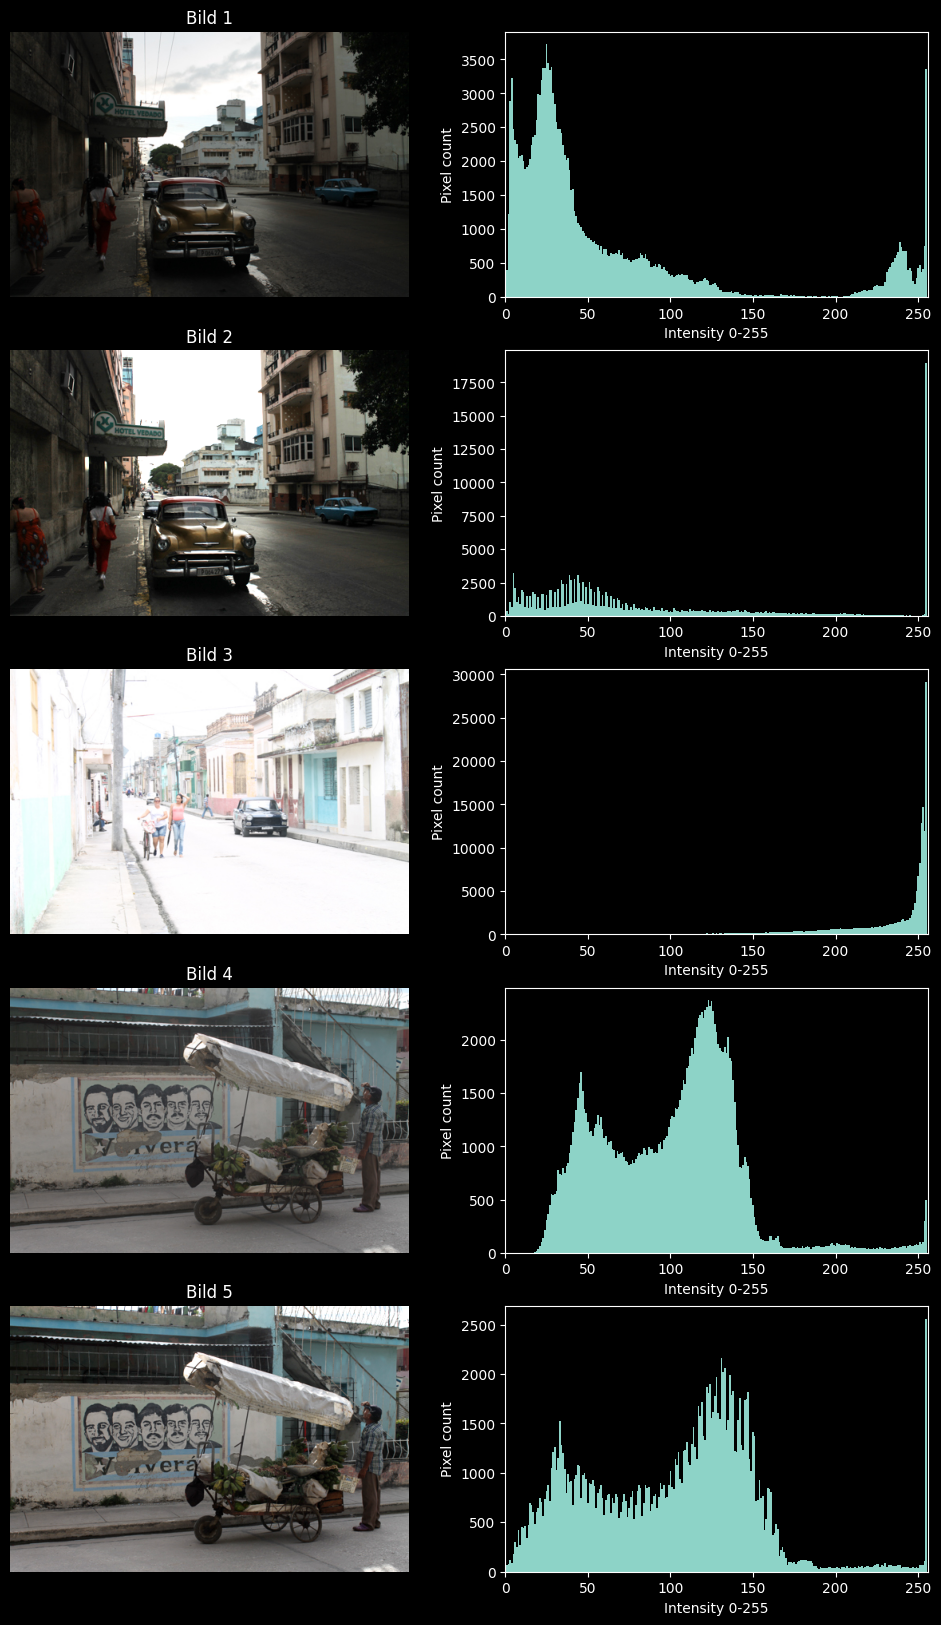

In [105]:
fig, axis = plt.subplots(5, 2, figsize=(12, 20))
# bild 1
h1 = computeHisto(bild1)
axis[0,0].imshow(bild1)
axis[0,0].axis('off')
axis[0,0].set_title('Bild 1')

axis[0,1].bar(range(256), h1, width = 1)
axis[0,1].set_xlabel('Intensity 0-255')
axis[0,1].set_ylabel('Pixel count')
axis[0,1].set_xlim(0,256)


# bild 2
h2 = computeHisto(bild2)

axis[1,0].imshow(bild2)
axis[1,0].axis('off')
axis[1,0].set_title('Bild 2')

axis[1,1].bar(range(256), h2, width = 1)
axis[1,1].set_xlabel('Intensity 0-255')
axis[1,1].set_ylabel('Pixel count')
axis[1,1].set_xlim(0,256)

# bild 3
h3 = computeHisto(bild3)

axis[2,0].imshow(bild3)
axis[2,0].axis('off')
axis[2,0].set_title('Bild 3')

axis[2,1].bar(range(256), h3, width = 1)
axis[2,1].set_xlabel('Intensity 0-255')
axis[2,1].set_ylabel('Pixel count')
axis[2,1].set_xlim(0,256)


# bild 4
h4 = computeHisto(bild4)

axis[3,0].imshow(bild4)
axis[3,0].axis('off')
axis[3,0].set_title('Bild 4')

axis[3,1].bar(range(256), h4, width = 1)
axis[3,1].set_xlabel('Intensity 0-255')
axis[3,1].set_ylabel('Pixel count')
axis[3,1].set_xlim(0,256)

# bild 5
h5 = computeHisto(bild5)

axis[4,0].imshow(bild5)
axis[4,0].axis('off')
axis[4,0].set_title('Bild 5')

axis[4,1].bar(range(256), h5, width = 1)
axis[4,1].set_xlabel('Intensity 0-255')
axis[4,1].set_ylabel('Pixel count')
axis[4,1].set_xlim(0,256)

a)
Bild 1:
- unterbelichtet, da am unteren Ende der Intensitätsskala eine Häufung zu erkennen ist und am oberen Ende die Skala überwiegend ungenutzt bleibt

Bild 3:
- überbelichtet, da das untere Ende der Intensitätsskala überwiegend ungenutzt bleibt, während am oberen Ende eine Häufung zu erkennen ist

b)
Bild 2:
- Histogram wurde nach rechts verschoben
- Die Werte wurden auseinandergezogen (Kamm - muster) -> Lücken zwischen den Balken
- Extreme Spitze bei 255 -> alle pixel die über 255 hinausgehen werden auf 255 gesetzt

c)
Bild 4 und 5:
- Kontrast



5. Implementieren Sie eine Funktion, die eine Punktoperation mithilfe einer Lookup-Tabelle
zum Aufhellen eines Bildes durchführt.

a) bei der einfachen addition gehen daten verloren, weil werte über 255 abgeschnitten werden, mit einer lut kann man eine nichtlineare Kurve wenden:

-> dunkel (0-100)
-> mittel (100-200)
-> hell (200-255)

γ = 1
straight diagonal line
→ no change

γ < 1 (e.g. 0.5)
curve bends upwards
→ dark values get brighter

γ > 1 (e.g. 2.0)
curve bends downwards
→ image gets darker

(0.0, 256.0)

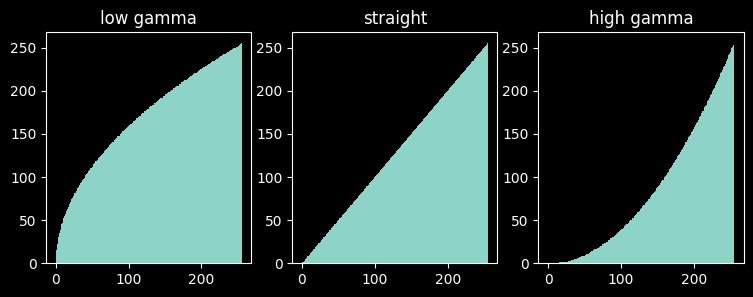

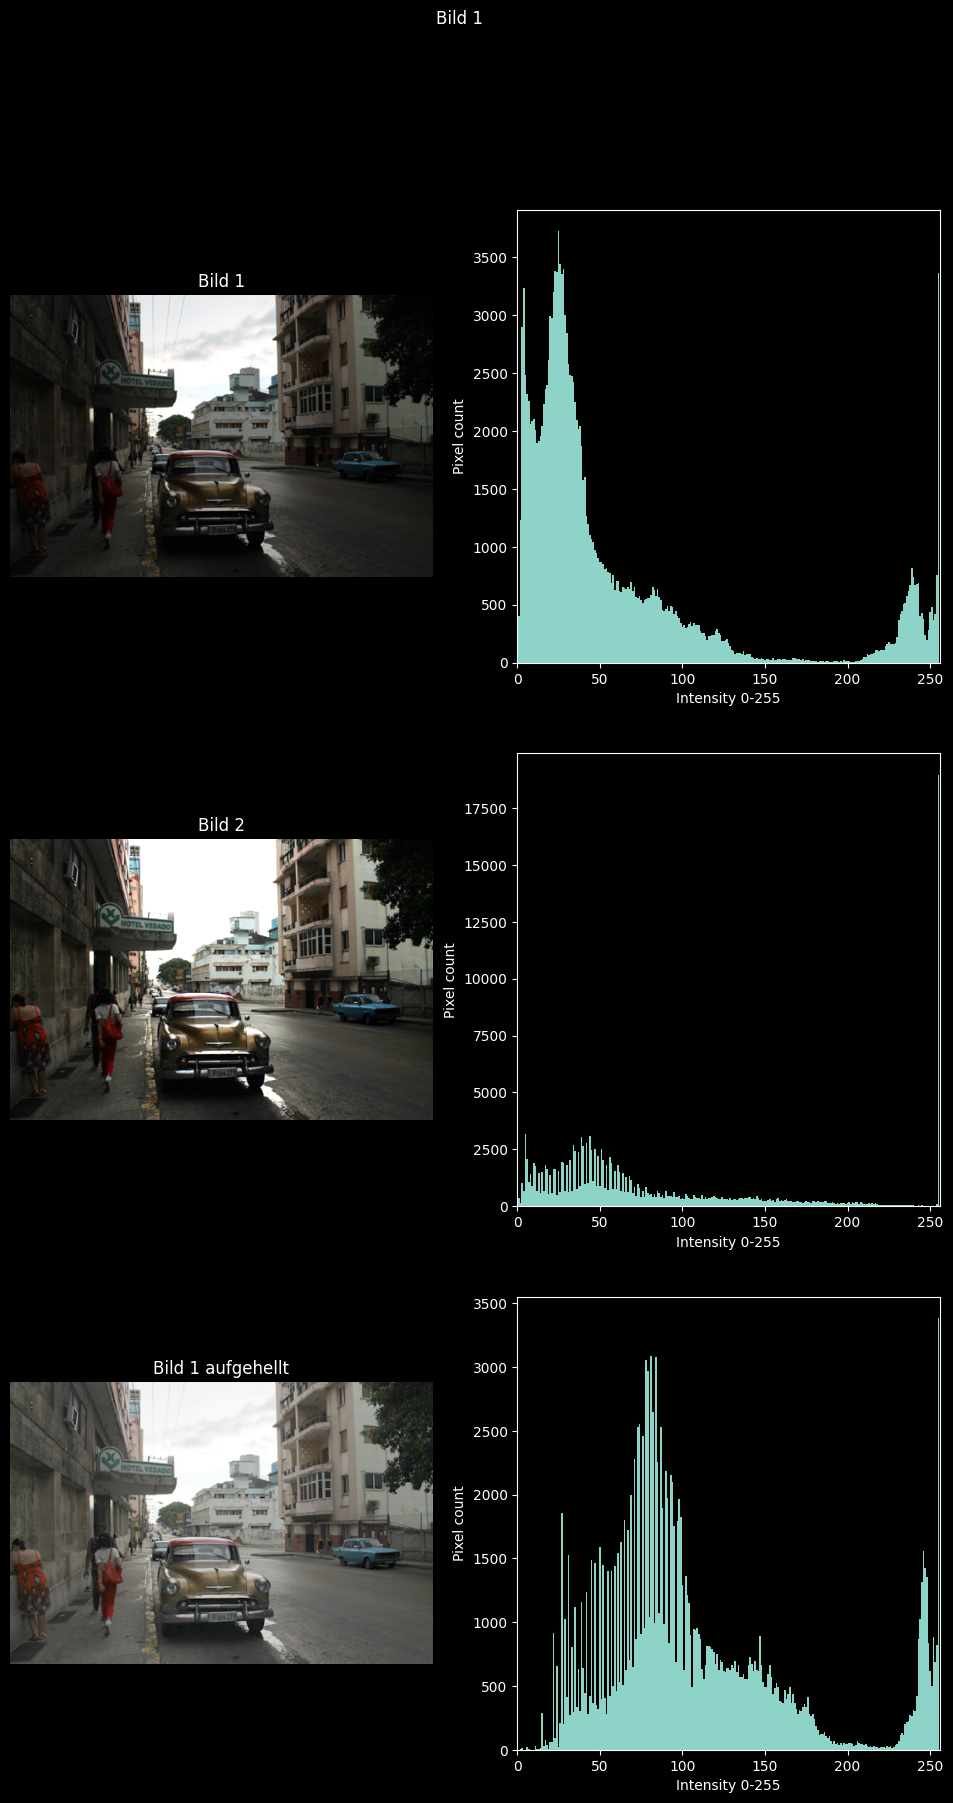

In [106]:
def create_lut_gamma(g):
    # erstelle eine leere lut mit 256 Einträgen -> einen pro möglichem Pixelwert 0-255
    lut = np.zeros(256, dtype=np.uint8)

    # berechne für jeden möglichen pixelwert den neuen wert
    # das wird 256 mal berechnet, egal wie groß das Bild ist
    for i in range(256):
        # gamma formel aus tabelle 5.2: (I/255)^g * 255
        # g < 1 → dunkle Werte stark aufhellen, helle kaum verändern
        # g > 1 → Bild verdunkeln
        lut[i] = np.uint8((i/255) ** g * 255)
    return lut

def apply_lut(image_array, lut):
    return lut[image_array]


lookup_table_low_gamma = create_lut_gamma(0.5)
lookup_table_straight = create_lut_gamma(1.0)
lookup_table_high_gamma = create_lut_gamma(2.0)


fig, axis = plt.subplots(1, 3, figsize=(9, 3))
axis[0].bar(range(256), lookup_table_low_gamma, width = 1)
axis[0].set_title('low gamma')

axis[1].bar(range(256), lookup_table_straight, width = 1)
axis[1].set_title('straight')

axis[2].bar(range(256), lookup_table_high_gamma, width = 1)
axis[2].set_title('high gamma')



bild1_aufgehellt = apply_lut(bild1, lookup_table_low_gamma)

h1a = computeHisto(bild1_aufgehellt)

fig, axis = plt.subplots(3, 2, figsize=(12, 20))
fig.suptitle('Bild 1')

# bild 1
h1 = computeHisto(bild1)
axis[0,0].imshow(bild1)
axis[0,0].axis('off')
axis[0,0].set_title('Bild 1')

axis[0,1].bar(range(256), h1, width = 1)
axis[0,1].set_xlabel('Intensity 0-255')
axis[0,1].set_ylabel('Pixel count')
axis[0,1].set_xlim(0,256)



# bild 2
axis[1,0].imshow(bild2)
axis[1,0].axis('off')
axis[1,0].set_title('Bild 2')


axis[1,1].bar(range(256), h2, width = 1)
axis[1,1].set_xlabel('Intensity 0-255')
axis[1,1].set_ylabel('Pixel count')
axis[1,1].set_xlim(0,256)


# bild 1 aufgehellt
axis[2,0].imshow(bild1_aufgehellt)
axis[2,0].axis('off')
axis[2,0].set_title('Bild 1 aufgehellt')


axis[2,1].bar(range(256), h1a, width = 1)
axis[2,1].set_xlabel('Intensity 0-255')
axis[2,1].set_ylabel('Pixel count')
axis[2,1].set_xlim(0,256)